# Course 1: Supervised Machine Learning - Regression and Classification

## Complete Summary with Theory and Practice

This comprehensive notebook summarizes all key concepts from Course 1 of the Machine Learning Specialization, covering supervised learning fundamentals including regression and classification algorithms.

---

## Table of Contents
1. [Introduction to Machine Learning](#intro)
2. [Linear Regression with One Variable](#linear-reg-1)
3. [Linear Regression with Multiple Variables](#linear-reg-multi)
4. [Logistic Regression](#logistic-reg)
5. [Regularization](#regularization)
6. [Practical Implementation Tips](#practical-tips)

---

<a name="intro"></a>
## 1. Introduction to Machine Learning

### What is Machine Learning?

Machine Learning is the field of study that gives computers the ability to learn without being explicitly programmed. In this course, we focus on **supervised learning**, where we learn from labeled training data.

### Types of Machine Learning

1. **Supervised Learning**: Learning from labeled data (input → output mapping)
   - Regression: Predict continuous values
   - Classification: Predict discrete categories

2. **Unsupervised Learning**: Learning from unlabeled data
   - Clustering, anomaly detection, dimensionality reduction

3. **Reinforcement Learning**: Learning through interaction with an environment

### Key Terminology

| Term | Symbol | Description |
|------|---------|-------------|
| Training example | $(x, y)$ | Input-output pair |
| Features | $x$ | Input variables |
| Target | $y$ | Output variable (what we predict) |
| Number of examples | $m$ | Size of training set |
| Number of features | $n$ | Dimensionality of input |
| Hypothesis/Model | $f_{w,b}(x)$ or $h_\theta(x)$ | Function that maps inputs to outputs |
| Parameters | $w, b$ (or $\theta$) | Values that define the model |

<a name="linear-reg-1"></a>
## 2. Linear Regression with One Variable

### Model Representation

Linear regression with one variable (univariate) predicts a continuous output based on a single input feature.

**Model equation:**
$$f_{w,b}(x) = wx + b$$

Where:
- $w$ is the weight (slope)
- $b$ is the bias (y-intercept)
- $x$ is the input feature

This is also called **simple linear regression** or **univariate linear regression**.

### Cost Function (Mean Squared Error)

The cost function measures how well our model fits the training data. We use the **squared error cost function**:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

**Simplified notation:**
$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

Where:
- $m$ is the number of training examples
- $\hat{y}^{(i)} = f_{w,b}(x^{(i)})$ is the predicted value
- $y^{(i)}$ is the actual target value
- The factor $\frac{1}{2}$ is for convenience in calculus (makes derivatives cleaner)

**Goal**: Find values of $w$ and $b$ that minimize $J(w,b)$

### Gradient Descent Algorithm

Gradient descent is an optimization algorithm to find the minimum of the cost function.

**Algorithm:**

Repeat until convergence {
$$w := w - \alpha \frac{\partial J(w,b)}{\partial w}$$
$$b := b - \alpha \frac{\partial J(w,b)}{\partial b}$$
}

Where $\alpha$ is the **learning rate** (controls step size).

**Partial derivatives for linear regression:**
$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$$

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$$

**Important Notes:**
- Update $w$ and $b$ simultaneously (use temporary variables)
- Learning rate $\alpha$ must be chosen carefully:
  - Too small: slow convergence
  - Too large: may not converge (diverge)
- The cost function for linear regression is always **convex** (bowl-shaped), so gradient descent will find the global minimum

Training examples: 3
x_train: [1. 2. 3.]
y_train: [300 500 700]
Iteration    0: Cost 1.23e+05, w:  1.133e+01, b: 5.00000e+00
Iteration  100: Cost 7.07e+00, w:  2.033e+02, b: 9.07987e+01
Iteration  200: Cost 4.49e+00, w:  2.035e+02, b: 9.20909e+01
Iteration  300: Cost 3.53e+00, w:  2.031e+02, b: 9.29879e+01
Iteration  400: Cost 2.77e+00, w:  2.027e+02, b: 9.37825e+01
Iteration  500: Cost 2.18e+00, w:  2.024e+02, b: 9.44871e+01
Iteration  600: Cost 1.71e+00, w:  2.022e+02, b: 9.51118e+01
Iteration  700: Cost 1.35e+00, w:  2.019e+02, b: 9.56657e+01
Iteration  800: Cost 1.06e+00, w:  2.017e+02, b: 9.61569e+01
Iteration  900: Cost 8.33e-01, w:  2.015e+02, b: 9.65924e+01

Final parameters: w = 201.33, b = 96.97
Final cost: 0.66

Prediction for x = 2.5: y = 600.30


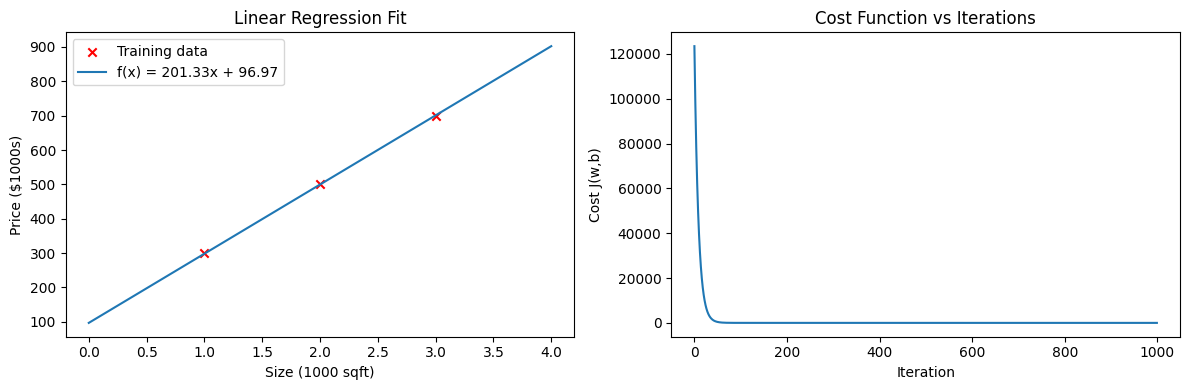

In [5]:
### Code Example: Linear Regression from Scratch

import numpy as np
import matplotlib.pyplot as plt

# Sample dataset: House size (1000 sqft) vs Price ($1000s)
x_train = np.array([1.0, 2.0, 3.0])  # House sizes
y_train = np.array([300, 500, 700])   # Prices
m = len(x_train)

print(f"Training examples: {m}")
print(f"x_train: {x_train}")
print(f"y_train: {y_train}")

# Model function
def compute_model_output(x, w, b):
    """
    Computes f_wb(x) = wx + b
    """
    return w * x + b

# Cost function
def compute_cost(x, y, w, b):
    """
    Computes the cost J(w,b)
    """
    m = x.shape[0]
    cost_sum = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost_sum += (f_wb - y[i]) ** 2
    
    total_cost = cost_sum / (2 * m)
    return total_cost

# Gradient computation
def compute_gradient(x, y, w, b):
    """
    Computes gradients dj_dw and dj_db
    """
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

# Gradient Descent
def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
    """
    Performs gradient descent to learn w and b
    """
    w = w_init
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        # Calculate gradients
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        
        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Save cost every iteration
        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i:4}: Cost {cost:0.2e}, w: {w: 0.3e}, b:{b: 0.5e}")
    
    return w, b, cost_history

# Run gradient descent
w_init = 0
b_init = 0
iterations = 1000
alpha = 0.01

w_final, b_final, cost_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)

print(f"\nFinal parameters: w = {w_final:.2f}, b = {b_final:.2f}")
print(f"Final cost: {cost_history[-1]:.2f}")

# Make predictions
x_test = 2.5
y_pred = compute_model_output(x_test, w_final, b_final)
print(f"\nPrediction for x = {x_test}: y = {y_pred:.2f}")

# Visualize
plt.figure(figsize=(12, 4))

# Plot 1: Data and fitted line
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, marker='x', c='r', label='Training data')
x_line = np.linspace(0, 4, 100)
y_line = w_final * x_line + b_final
plt.plot(x_line, y_line, label=f'f(x) = {w_final:.2f}x + {b_final:.2f}')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price ($1000s)')
plt.title('Linear Regression Fit')
plt.legend()

# Plot 2: Cost history
plt.subplot(1, 2, 2)
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Cost Function vs Iterations')
plt.tight_layout()
plt.show()

<a name="linear-reg-multi"></a>
## 3. Linear Regression with Multiple Variables (Multiple Features)

### Model Representation

When we have multiple input features, the model becomes:

$$f_{\mathbf{w},b}(\mathbf{x}) = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

**Vectorized notation:**
$$f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b = \mathbf{w}^T\mathbf{x} + b$$

Where:
- $\mathbf{w} = [w_1, w_2, ..., w_n]$ is the weight vector
- $\mathbf{x} = [x_1, x_2, ..., x_n]$ is the feature vector
- $b$ is the bias term
- $n$ is the number of features

**Example**: House price prediction with 4 features
- $x_1$: size (sqft)
- $x_2$: number of bedrooms
- $x_3$: number of floors
- $x_4$: age of home

Model: $f_{\mathbf{w},b}(\mathbf{x}) = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b$

### Vectorization

Vectorization makes code more efficient by using NumPy's optimized operations instead of explicit loops.

**Without vectorization** (using loop):
```python
f = 0
for j in range(n):
    f += w[j] * x[j]
f += b
```

**With vectorization**:
```python
f = np.dot(w, x) + b
```

Vectorization is **much faster** (10-100x) and more concise!

### Cost Function for Multiple Variables

$$J(\mathbf{w},b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

Where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w}^T\mathbf{x}^{(i)} + b$

### Gradient Descent for Multiple Variables

**Algorithm:**

Repeat until convergence {

$$w_j := w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \quad \text{for } j = 1, ..., n$$

$$b := b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}$$

}

**Gradients:**
$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

### Feature Scaling

When features have very different ranges, gradient descent can be slow. **Feature scaling** makes all features have similar ranges.

**Common techniques:**

1. **Feature Scaling** (division by max):
   $$x_j^{(i)} := \frac{x_j^{(i)}}{\max(x_j)}$$

2. **Mean Normalization**:
   $$x_j^{(i)} := \frac{x_j^{(i)} - \mu_j}{\max(x_j) - \min(x_j)}$$

3. **Z-score Normalization** (standardization):
   $$x_j^{(i)} := \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$
   
   Where $\mu_j$ is mean and $\sigma_j$ is standard deviation

**Rule of thumb**: Aim for features to be roughly in the range $-1 \leq x_j \leq 1$

### Feature Engineering

Creating new features from existing ones to improve model performance.

**Examples:**
- Area = width × length (from two features to one)
- Polynomial features: $x, x^2, x^3$ for non-linear relationships
- Combining features: e.g., price per sqft = price / size

### Polynomial Regression

Fit non-linear functions by treating powers of $x$ as separate features:

$$f_{\mathbf{w},b}(x) = w_1x + w_2x^2 + w_3x^3 + b$$

Or with square root:
$$f_{\mathbf{w},b}(x) = w_1x + w_2\sqrt{x} + b$$

**Important**: Feature scaling becomes crucial for polynomial features!

In [6]:
### Code Example: Multiple Linear Regression with Vectorization

import numpy as np
import copy
import math

# Multiple feature dataset: [size, bedrooms, floors, age] -> price
X_train = np.array([[2104, 5, 1, 45], 
                     [1416, 3, 2, 40], 
                     [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

print("Training Data:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nX_train:\n{X_train}")
print(f"\ny_train: {y_train}\n")

# Vectorized prediction
def predict(X, w, b):
    """
    Vectorized prediction for multiple examples
    X: (m, n) matrix
    w: (n,) vector
    b: scalar
    """
    return np.dot(X, w) + b

# Vectorized cost function
def compute_cost(X, y, w, b):
    """
    Compute cost using vectorization
    """
    m = X.shape[0]
    predictions = predict(X, w, b)
    cost = np.sum((predictions - y) ** 2) / (2 * m)
    return cost

# Vectorized gradient
def compute_gradient(X, y, w, b):
    """
    Compute gradients using vectorization
    """
    m, n = X.shape
    predictions = predict(X, w, b)
    error = predictions - y
    
    dj_dw = np.dot(X.T, error) / m
    dj_db = np.sum(error) / m
    
    return dj_dw, dj_db

# Gradient descent
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """
    Gradient descent for multiple variables
    """
    w = copy.deepcopy(w_init)
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        if i < 100000:
            cost_history.append(compute_cost(X, y, w, b))
        
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e}")
    
    return w, b, cost_history

# Feature Scaling using Z-score normalization
def zscore_normalize_features(X):
    """
    Normalize features using z-score
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalize the features
X_norm, mu, sigma = zscore_normalize_features(X_train)
print(f"Original X_train:\n{X_train}")
print(f"\nNormalized X_norm:\n{X_norm}")
print(f"\nMean (mu): {mu}")
print(f"Std (sigma): {sigma}\n")

# Initialize parameters
n = X_train.shape[1]
w_init = np.zeros(n)
b_init = 0

# Run gradient descent on normalized features
alpha = 0.01
iterations = 1000

w_final, b_final, cost_history = gradient_descent(X_norm, y_train, w_init, b_init, alpha, iterations)

print(f"\nFinal parameters:")
print(f"w: {w_final}")
print(f"b: {b_final:.3f}")

# Make a prediction (must normalize the input!)
x_test = np.array([1200, 3, 1, 40])  # Example house
x_test_norm = (x_test - mu) / sigma
y_pred = predict(x_test_norm.reshape(1, -1), w_final, b_final)
print(f"\nPrediction for {x_test}: ${y_pred[0]:.2f}k")

# Using sklearn for comparison
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_norm, y_train)
print(f"\nSklearn prediction: ${model.predict(x_test_norm.reshape(1, -1))[0]:.2f}k")
print(f"Sklearn coefficients: {model.coef_}")
print(f"Sklearn intercept: {model.intercept_:.3f}")

Training Data:
X_train shape: (3, 4)
y_train shape: (3,)

X_train:
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]

y_train: [460 232 178]

Original X_train:
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]

Normalized X_norm:
[[ 1.26311506  1.33630621 -0.70710678  1.22474487]
 [-0.08073519 -0.26726124  1.41421356  0.        ]
 [-1.18237987 -1.06904497 -0.70710678 -1.22474487]]

Mean (mu): [1.45733333e+03 3.33333333e+00 1.33333333e+00 4.00000000e+01]
Std (sigma): [5.11961804e+02 1.24721913e+00 4.71404521e-01 4.08248290e+00]

Iteration    0: Cost 4.83e+04
Iteration  100: Cost 5.58e+03
Iteration  200: Cost 7.46e+02
Iteration  300: Cost 9.99e+01
Iteration  400: Cost 1.34e+01
Iteration  500: Cost 1.79e+00
Iteration  600: Cost 2.40e-01
Iteration  700: Cost 3.22e-02
Iteration  800: Cost 4.31e-03
Iteration  900: Cost 5.77e-04

Final parameters:
w: [ 38.05168398  41.54320558 -30.98791712  36.34190238]
b: 289.987

Prediction for [1200    3    1   40]: 

<a name="logistic-reg"></a>
## 4. Logistic Regression (Classification)

### Introduction to Classification

Unlike regression (predicting continuous values), classification predicts discrete categories.

**Binary Classification**: Output $y \in \{0, 1\}$
- 0: Negative class (e.g., not spam, benign tumor)
- 1: Positive class (e.g., spam, malignant tumor)

### Why Not Linear Regression for Classification?

Linear regression can output values $< 0$ or $> 1$, which doesn't make sense for probabilities. We need an algorithm that outputs values between 0 and 1.

### Sigmoid Function (Logistic Function)

The sigmoid function maps any real number to the range (0, 1):

$$g(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- $g(z) \to 1$ as $z \to \infty$
- $g(z) \to 0$ as $z \to -\infty$
- $g(0) = 0.5$
- $g(-z) = 1 - g(z)$

### Logistic Regression Model

$$f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

Where $z = \mathbf{w}^T\mathbf{x} + b$

**Interpretation**: $f_{\mathbf{w},b}(\mathbf{x})$ represents the probability that $y = 1$ given input $\mathbf{x}$

$$f_{\mathbf{w},b}(\mathbf{x}) = P(y=1|\mathbf{x};\mathbf{w},b)$$

### Decision Boundary

To make a prediction, we use a threshold (typically 0.5):

- Predict $\hat{y} = 1$ if $f_{\mathbf{w},b}(\mathbf{x}) \geq 0.5$, which means $z \geq 0$
- Predict $\hat{y} = 0$ if $f_{\mathbf{w},b}(\mathbf{x}) < 0.5$, which means $z < 0$

**Decision boundary**: The line/surface where $\mathbf{w}^T\mathbf{x} + b = 0$

**Examples:**
- Linear: $w_1x_1 + w_2x_2 + b = 0$
- Non-linear: $w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + b = 0$ (circular boundary)

### Cost Function for Logistic Regression

**Why not squared error?**
Using $(f_{\mathbf{w},b}(\mathbf{x}) - y)^2$ with sigmoid creates a non-convex function with many local minima. Gradient descent won't work well!

**Logistic Loss Function:**

For a single training example:

$$L(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
-\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) & \text{if } y^{(i)} = 1 \\
-\log(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})) & \text{if } y^{(i)} = 0
\end{cases}$$

**Intuition:**
- If $y = 1$ and $f = 1$: loss = 0 (perfect!)
- If $y = 1$ and $f \to 0$: loss $\to \infty$ (heavily penalized!)
- If $y = 0$ and $f = 0$: loss = 0 (perfect!)
- If $y = 0$ and $f \to 1$: loss $\to \infty$ (heavily penalized!)

**Simplified cost function (works for both y=0 and y=1):**

$$L(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)}\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) - (1-y^{(i)})\log(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)}))$$

**Total cost (over all examples):**

$$J(\mathbf{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1-y^{(i)})\log(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})) \right]$$

This is called **binary cross-entropy** or **log loss**.

### Gradient Descent for Logistic Regression

**Algorithm:**

Repeat until convergence {

$$w_j := w_j - \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j}$$

$$b := b - \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}$$

}

**Gradients** (same form as linear regression, but $f$ is different!):

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)}$$

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

Where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x}^{(i)} + b)}}$

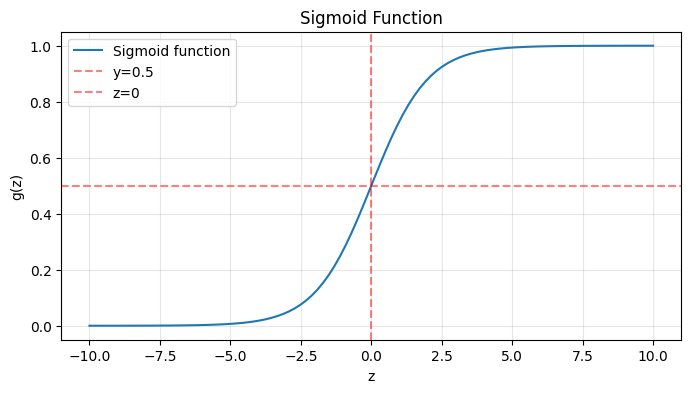

sigmoid(0) = 0.5
sigmoid(large positive) = 1.0
sigmoid(large negative) = 3.7200759760208356e-44

Training data shape: X=(6, 2), y=(6,)
Iteration    0: Cost 0.6846
Iteration 1000: Cost 0.1591
Iteration 2000: Cost 0.0846
Iteration 3000: Cost 0.0571
Iteration 4000: Cost 0.0429
Iteration 5000: Cost 0.0343
Iteration 6000: Cost 0.0286
Iteration 7000: Cost 0.0245
Iteration 8000: Cost 0.0214
Iteration 9000: Cost 0.0190

Final parameters:
w = [5.28123029 5.07815608]
b = -14.2224

Predictions:
x=[0.5 1.5], True y=0, Predicted y=0, P(y=1)=0.019
x=[1. 1.], True y=0, Predicted y=0, P(y=1)=0.021
x=[1.5 0.5], True y=0, Predicted y=0, P(y=1)=0.023
x=[3.  0.5], True y=1, Predicted y=1, P(y=1)=0.985
x=[2. 2.], True y=1, Predicted y=1, P(y=1)=0.998
x=[1.  2.5], True y=1, Predicted y=1, P(y=1)=0.977

Training Accuracy: 100.00%


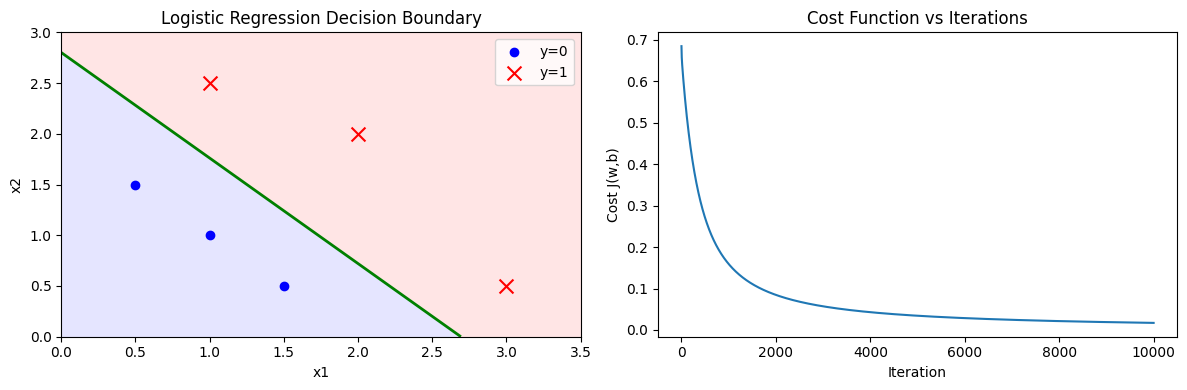


Sklearn Logistic Regression Accuracy: 100.00%
Sklearn coefficients: [0.90411349 0.73587543]
Sklearn intercept: -2.3337


In [7]:
### Code Example: Logistic Regression from Scratch

import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    """
    Compute sigmoid function g(z) = 1 / (1 + e^(-z))
    """
    return 1 / (1 + np.exp(-z))

# Test sigmoid
z = np.linspace(-10, 10, 100)
g_z = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, g_z, label='Sigmoid function')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='y=0.5')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='z=0')
plt.xlabel('z')
plt.ylabel('g(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"sigmoid(0) = {sigmoid(0)}")
print(f"sigmoid(large positive) = {sigmoid(100)}")
print(f"sigmoid(large negative) = {sigmoid(-100)}")

# Sample dataset
X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

print(f"\nTraining data shape: X={X_train.shape}, y={y_train.shape}")

# Prediction function
def predict_logistic(X, w, b):
    """
    Predict using logistic regression
    """
    z = np.dot(X, w) + b
    return sigmoid(z)

# Cost function
def compute_cost_logistic(X, y, w, b):
    """
    Compute logistic regression cost
    """
    m = X.shape[0]
    f_wb = predict_logistic(X, w, b)
    
    # Avoid log(0) by adding small epsilon
    epsilon = 1e-10
    cost = -np.mean(y * np.log(f_wb + epsilon) + (1 - y) * np.log(1 - f_wb + epsilon))
    
    return cost

# Gradient function
def compute_gradient_logistic(X, y, w, b):
    """
    Compute gradients for logistic regression
    """
    m, n = X.shape
    f_wb = predict_logistic(X, w, b)
    error = f_wb - y
    
    dj_dw = np.dot(X.T, error) / m
    dj_db = np.mean(error)
    
    return dj_dw, dj_db

# Gradient descent
def gradient_descent_logistic(X, y, w_init, b_init, alpha, num_iters):
    """
    Perform gradient descent for logistic regression
    """
    w = np.copy(w_init)
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost_logistic(X, y, w, b)
        cost_history.append(cost)
        
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4}: Cost {cost:.4f}")
    
    return w, b, cost_history

# Train the model
n_features = X_train.shape[1]
w_init = np.zeros(n_features)
b_init = 0
alpha = 0.1
iterations = 10000

w_final, b_final, cost_history = gradient_descent_logistic(X_train, y_train, w_init, b_init, alpha, iterations)

print(f"\nFinal parameters:")
print(f"w = {w_final}")
print(f"b = {b_final:.4f}")

# Make predictions
predictions = predict_logistic(X_train, w_final, b_final)
y_pred = (predictions >= 0.5).astype(int)

print(f"\nPredictions:")
for i in range(len(X_train)):
    print(f"x={X_train[i]}, True y={y_train[i]}, Predicted y={y_pred[i]}, P(y=1)={predictions[i]:.3f}")

# Calculate accuracy
accuracy = np.mean(y_pred == y_train) * 100
print(f"\nTraining Accuracy: {accuracy:.2f}%")

# Visualize decision boundary
plt.figure(figsize=(12, 4))

# Plot 1: Training data and decision boundary
plt.subplot(1, 2, 1)
# Plot data points
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], 
            marker='o', c='blue', label='y=0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 
            marker='x', c='red', s=100, label='y=1')

# Plot decision boundary
x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))
X_mesh = np.c_[xx1.ravel(), xx2.ravel()]
Z = predict_logistic(X_mesh, w_final, b_final).reshape(xx1.shape)

plt.contour(xx1, xx2, Z, levels=[0.5], colors='green', linewidths=2)
plt.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], colors=['blue', 'red'], alpha=0.1)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()

# Plot 2: Cost history
plt.subplot(1, 2, 2)
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Cost Function vs Iterations')
plt.tight_layout()
plt.show()

# Using sklearn for comparison
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression()
sklearn_model.fit(X_train, y_train)
sklearn_pred = sklearn_model.predict(X_train)
sklearn_accuracy = np.mean(sklearn_pred == y_train) * 100

print(f"\nSklearn Logistic Regression Accuracy: {sklearn_accuracy:.2f}%")
print(f"Sklearn coefficients: {sklearn_model.coef_[0]}")
print(f"Sklearn intercept: {sklearn_model.intercept_[0]:.4f}")

<a name="regularization"></a>
## 5. Regularization (Addressing Overfitting)

### The Problem of Overfitting

**Underfitting (High Bias)**:
- Model is too simple
- Poor performance on both training and test data
- Example: linear model for clearly non-linear data

**Good Fit (Just Right)**:
- Model captures the underlying pattern
- Good performance on both training and test data

**Overfitting (High Variance)**:
- Model is too complex
- Excellent performance on training data, poor on test data
- Model memorizes training data instead of learning general patterns
- Example: high-degree polynomial fits training noise

### Solutions to Overfitting

1. **Collect more training data**: More data helps the model generalize
2. **Feature selection**: Use fewer features, remove irrelevant ones
3. **Regularization**: Keep all features but reduce their impact (penalize large parameters)

### Regularization Concept

**Idea**: Penalize large parameter values to keep the model simpler.

Add a regularization term to the cost function:

**For Linear Regression:**
$$J(\mathbf{w},b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$$

**For Logistic Regression:**
$$J(\mathbf{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1-y^{(i)})\log(1-f_{\mathbf{w},b}(\mathbf{x}^{(i)}))\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$$

Where:
- $\lambda$ is the **regularization parameter** (controls strength of regularization)
- The term $\frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ is the **regularization term** (also called L2 regularization or weight decay)
- **Note**: We typically don't regularize $b$ (the bias term)

### Choosing Lambda (λ)

- $\lambda = 0$: No regularization → possible overfitting
- $\lambda$ too large: Severe underfitting (parameters become too small)
- $\lambda$ just right: Good balance between fitting training data and generalizing

**Common values**: Try $\lambda \in \{0.01, 0.03, 0.1, 0.3, 1, 3, 10\}$ and use validation set to choose

### Regularized Gradient Descent

**For Linear Regression:**

Repeat until convergence {

$$w_j := w_j - \alpha \left[\frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \cdot x_j^{(i)} + \frac{\lambda}{m}w_j\right]$$

$$b := b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

}

This can be rewritten as:
$$w_j := w_j(1 - \alpha\frac{\lambda}{m}) - \alpha\frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

The term $(1 - \alpha\frac{\lambda}{m})$ is slightly less than 1, so this "shrinks" $w_j$ each iteration (weight decay).

**For Logistic Regression:** (same equations, different $f_{\mathbf{w},b}$)

Repeat until convergence {

$$w_j := w_j - \alpha \left[\frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \cdot x_j^{(i)} + \frac{\lambda}{m}w_j\right]$$

$$b := b - \alpha \frac{1}{m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

}

Where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x}^{(i)} + b)}}$

Training set size: 80
Validation set size: 20
Original features: 2
Polynomial features: 27

Training with λ = 0
Iteration 0: Cost 0.5957
Iteration 1000: Cost 0.3596
Iteration 2000: Cost 0.3058
Iteration 3000: Cost 0.2804
Iteration 4000: Cost 0.2660
Training Accuracy: 91.25%
Validation Accuracy: 85.00%

Training with λ = 0.1
Iteration 0: Cost 0.5957
Iteration 1000: Cost 0.3604
Iteration 2000: Cost 0.3077
Iteration 3000: Cost 0.2834
Iteration 4000: Cost 0.2700
Training Accuracy: 91.25%
Validation Accuracy: 85.00%

Training with λ = 1
Iteration 0: Cost 0.5957
Iteration 1000: Cost 0.3670
Iteration 2000: Cost 0.3228
Iteration 3000: Cost 0.3057
Iteration 4000: Cost 0.2980
Training Accuracy: 92.50%
Validation Accuracy: 85.00%

Training with λ = 10
Iteration 0: Cost 0.5958
Iteration 1000: Cost 0.4045
Iteration 2000: Cost 0.3845
Iteration 3000: Cost 0.3797
Iteration 4000: Cost 0.3784
Training Accuracy: 87.50%
Validation Accuracy: 85.00%


C:\Users\Javad\AppData\Local\Temp\ipykernel_11148\3782978206.py:40: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Javad\AppData\Local\Temp\ipykernel_11148\3782978206.py:40: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
C:\Users\Javad\AppData\Local\Temp\ipykernel_11148\3782978206.py:40: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


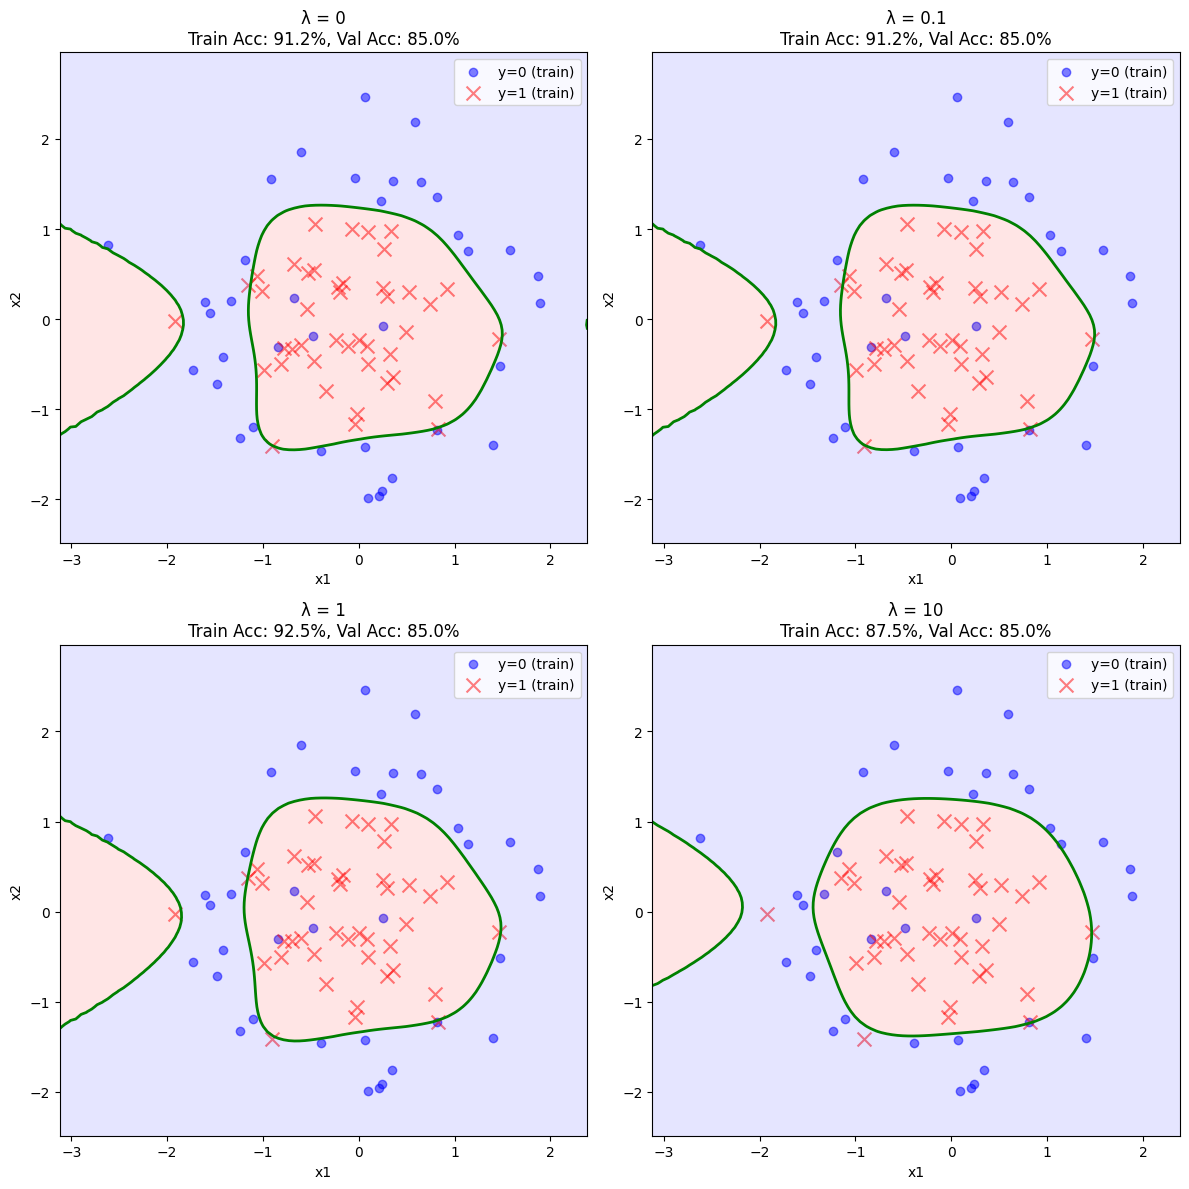


REGULARIZATION SUMMARY
    Lambda    Train Acc      Val Acc              Comment
------------------------------------------------------------
         0       91.25%       85.00%          Overfitting
       0.1       91.25%       85.00%         Good balance
         1       92.50%       85.00%         Good balance
        10       87.50%       85.00%         Underfitting


In [8]:
### Code Example: Regularized Logistic Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data with non-linear boundary
np.random.seed(42)
m = 100

# Create circular decision boundary dataset
X1 = np.random.randn(m, 2)
y1 = (X1[:, 0]**2 + X1[:, 1]**2 < 1.5).astype(int)

# Add some noise
noise_indices = np.random.choice(m, size=10, replace=False)
y1[noise_indices] = 1 - y1[noise_indices]

# Split into train and validation (simple split)
train_size = 80
X_train = X1[:train_size]
y_train = y1[:train_size]
X_val = X1[train_size:]
y_val = y1[train_size:]

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

# Create polynomial features (for non-linear decision boundary)
poly = PolynomialFeatures(degree=6, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

# Regularized logistic regression functions
def predict_logistic(X, w, b):
    z = np.dot(X, w) + b
    return 1 / (1 + np.exp(-z))

def compute_cost_regularized(X, y, w, b, lambda_):
    """
    Compute regularized logistic regression cost
    """
    m = X.shape[0]
    f_wb = predict_logistic(X, w, b)
    
    epsilon = 1e-10
    cost = -np.mean(y * np.log(f_wb + epsilon) + (1 - y) * np.log(1 - f_wb + epsilon))
    
    # Add regularization term
    reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)
    
    return cost + reg_cost

def compute_gradient_regularized(X, y, w, b, lambda_):
    """
    Compute regularized gradients
    """
    m, n = X.shape
    f_wb = predict_logistic(X, w, b)
    error = f_wb - y
    
    dj_dw = (np.dot(X.T, error) / m) + (lambda_ / m) * w  # Regularization added here
    dj_db = np.mean(error)  # No regularization for b
    
    return dj_dw, dj_db

def gradient_descent_regularized(X, y, w_init, b_init, alpha, num_iters, lambda_):
    """
    Regularized gradient descent
    """
    w = np.copy(w_init)
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_regularized(X, y, w, b, lambda_)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost_regularized(X, y, w, b, lambda_)
        cost_history.append(cost)
        
        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")
    
    return w, b, cost_history

# Train models with different lambda values
lambdas = [0, 0.1, 1, 10]
models = {}

for lambda_ in lambdas:
    print(f"\n{'='*50}")
    print(f"Training with λ = {lambda_}")
    print('='*50)
    
    n_features = X_train_poly.shape[1]
    w_init = np.zeros(n_features)
    b_init = 0
    
    w, b, cost_hist = gradient_descent_regularized(
        X_train_poly, y_train, w_init, b_init, 
        alpha=0.01, num_iters=5000, lambda_=lambda_
    )
    
    # Calculate accuracies
    train_pred = (predict_logistic(X_train_poly, w, b) >= 0.5).astype(int)
    val_pred = (predict_logistic(X_val_poly, w, b) >= 0.5).astype(int)
    
    train_acc = np.mean(train_pred == y_train) * 100
    val_acc = np.mean(val_pred == y_val) * 100
    
    print(f"Training Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    
    models[lambda_] = {'w': w, 'b': b, 'cost_hist': cost_hist, 
                       'train_acc': train_acc, 'val_acc': val_acc}

# Visualize decision boundaries for different lambda values
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for idx, lambda_ in enumerate(lambdas):
    ax = axes[idx]
    
    # Plot training data
    ax.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], 
               c='blue', marker='o', alpha=0.5, label='y=0 (train)')
    ax.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 
               c='red', marker='x', s=100, alpha=0.5, label='y=1 (train)')
    
    # Create decision boundary
    x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                           np.linspace(x2_min, x2_max, 100))
    
    X_mesh = np.c_[xx1.ravel(), xx2.ravel()]
    X_mesh_poly = poly.transform(X_mesh)
    
    w = models[lambda_]['w']
    b = models[lambda_]['b']
    Z = predict_logistic(X_mesh_poly, w, b).reshape(xx1.shape)
    
    ax.contour(xx1, xx2, Z, levels=[0.5], colors='green', linewidths=2)
    ax.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], colors=['blue', 'red'], alpha=0.1)
    
    train_acc = models[lambda_]['train_acc']
    val_acc = models[lambda_]['val_acc']
    
    ax.set_title(f'λ = {lambda_}\nTrain Acc: {train_acc:.1f}%, Val Acc: {val_acc:.1f}%')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()

plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*60}")
print("REGULARIZATION SUMMARY")
print('='*60)
print(f"{'Lambda':>10} {'Train Acc':>12} {'Val Acc':>12} {'Comment':>20}")
print('-'*60)
for lambda_ in lambdas:
    train_acc = models[lambda_]['train_acc']
    val_acc = models[lambda_]['val_acc']
    
    if lambda_ == 0:
        comment = "Overfitting"
    elif lambda_ <= 1:
        comment = "Good balance"
    else:
        comment = "Underfitting"
    
    print(f"{lambda_:>10} {train_acc:>11.2f}% {val_acc:>11.2f}% {comment:>20}")
print('='*60)

<a name="practical-tips"></a>
## 6. Practical Implementation Tips

### Vectorization Best Practices

**Why vectorization matters:**
- **Speed**: 10-100x faster than loops (uses optimized BLAS libraries)
- **Readability**: More concise code
- **Scalability**: Essential for large datasets

**Examples:**

```python
# Instead of:
f = 0
for j in range(n):
    f += w[j] * x[j]
f += b

# Use:
f = np.dot(w, x) + b
```

### Feature Scaling Guidelines

**When to use:**
- Features have very different ranges (e.g., size: 300-5000, bedrooms: 1-5)
- Polynomial features (x, x², x³ have vastly different ranges)
- Using gradient descent

**When NOT needed:**
- Using normal equation (direct solution)
- Tree-based algorithms (decision trees, random forests)

**Methods:**
1. **Division by maximum**: $x' = x / \max(x)$
2. **Mean normalization**: $x' = (x - \mu) / (\max - \min)$
3. **Z-score** (most common): $x' = (x - \mu) / \sigma$

**Target ranges:**
- Roughly $-3 \leq x \leq 3$ (Z-score)
- Or $-1 \leq x \leq 1$ (min-max scaling)

### Learning Rate Selection

**Debugging gradient descent:**
- Plot $J(\mathbf{w},b)$ vs iteration number
- Cost should decrease every iteration
- If cost increases: learning rate too large or bug in code
- If cost decreases slowly: learning rate too small or need more iterations

**Choosing α:**
- Start with small value (e.g., 0.001)
- Increase by 3x: try 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1
- Pick largest α that reliably decreases cost

**Convergence:**
- Declare convergence when $J(\mathbf{w},b)$ decreases by less than $\epsilon$ (e.g., $10^{-3}$)
- Or use fixed number of iterations

### Model Development Workflow

1. **Data Collection & Preprocessing**
   - Load and explore data
   - Handle missing values
   - Check for outliers

2. **Feature Engineering**
   - Create relevant features
   - Apply feature scaling
   - Add polynomial features if needed

3. **Split Data**
   - Training set (60-80%)
   - Validation set (10-20%) - for hyperparameter tuning
   - Test set (10-20%) - for final evaluation

4. **Train Model**
   - Choose algorithm (linear/logistic regression)
   - Initialize parameters
   - Run gradient descent
   - Monitor cost function

5. **Evaluate & Iterate**
   - Check training and validation accuracy
   - If underfitting: add features, decrease λ, increase model complexity
   - If overfitting: get more data, remove features, increase λ
   - Tune hyperparameters (α, λ, iterations)

6. **Test Final Model**
   - Evaluate on held-out test set
   - Report performance metrics

### Common Pitfalls to Avoid

1. **Not scaling features**: Can make gradient descent very slow
2. **Learning rate too large**: Cost diverges or oscillates
3. **Not enough iterations**: Model doesn't fully converge
4. **Using test set for tuning**: Leads to overly optimistic performance estimates
5. **Regularizing b**: Convention is to only regularize weights, not bias
6. **Forgetting to normalize new predictions**: Must use same μ and σ from training!

### Summary of Key Equations

| Concept | Equation |
|---------|----------|
| Linear Regression | $f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$ |
| Logistic Regression | $f_{\mathbf{w},b}(\mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$ |
| MSE Cost (Linear) | $J = \frac{1}{2m}\sum_{i=1}^{m}(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$ |
| Log Loss (Logistic) | $J = -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log(f) + (1-y^{(i)})\log(1-f)]$ |
| Gradient Descent | $w_j := w_j - \alpha \frac{\partial J}{\partial w_j}$ |
| Regularization Term | $\frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$ |
| Z-score Normalization | $x' = \frac{x - \mu}{\sigma}$ |

---

## Conclusion

This course covered the fundamentals of supervised learning:

**Linear Regression**: Predicting continuous values using gradient descent and the squared error cost function.

**Logistic Regression**: Binary classification using the sigmoid function and log loss.

**Key Techniques**:
- Gradient descent optimization
- Vectorization for efficiency
- Feature scaling for faster convergence
- Regularization to prevent overfitting
- Feature engineering for better models

**Next Steps**: Course 2 covers neural networks and advanced learning algorithms that build upon these foundations!

---

## Additional Resources

- **Notation Guide**: Review the notation section at the beginning
- **sklearn Documentation**: For production-ready implementations
- **Practice**: Implement these algorithms from scratch to solidify understanding
- **Kaggle**: Apply these techniques to real-world datasets